In [36]:
import tensorflow as tf
import keras
from tensorflow.keras import Sequential

In [60]:
from tensorflow.keras.layers import Dense
import numpy as np

In [38]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [39]:
from tensorflow.keras.datasets import mnist

In [40]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()

In [41]:
x_train.shape

(60000, 28, 28)

In [42]:
x_test.shape

(10000, 28, 28)

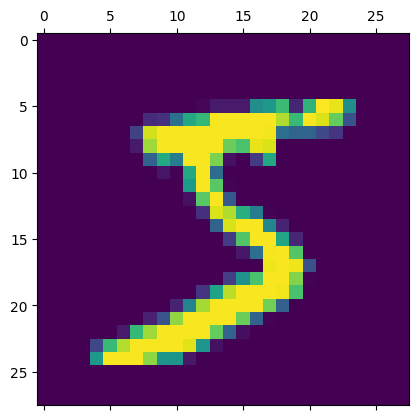

In [43]:
plt.matshow(x_train[0])

In [44]:
y_train[0]

5

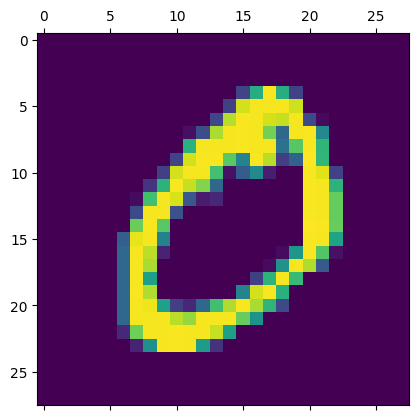

In [45]:
plt.matshow(x_train[1])

In [46]:
y_train[1]

0

In [47]:
x_train=x_train/255
x_test=x_test/255

In [48]:
x_train_f=x_train.reshape(len(x_train),28*28)
x_test_f=x_test.reshape(len(x_test),28*28)

In [49]:
model=keras.Sequential([
    keras.layers.Dense(10,input_shape=(784,),activation='relu'),
    keras.layers.Dense(10,activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [51]:
history=model.fit(x_train_f,y_train,epochs=10,batch_size=512,validation_data=(x_test_f,y_test))

Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.3683 - loss: 1.8977 - val_accuracy: 0.7803 - val_loss: 0.8716
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8087 - loss: 0.7548 - val_accuracy: 0.8677 - val_loss: 0.4897
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8753 - loss: 0.4645 - val_accuracy: 0.8991 - val_loss: 0.3845
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8950 - loss: 0.3837 - val_accuracy: 0.9081 - val_loss: 0.3373
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9052 - loss: 0.3384 - val_accuracy: 0.9138 - val_loss: 0.3122
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9095 - loss: 0.3225 - val_accuracy: 0.9185 - val_loss: 0.2959
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9157 - loss: 0.3042 - val_accuracy: 0.9195 - val_loss: 0.2864
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9197 - loss: 0.2887 - val_accuracy: 0.

In [52]:
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(1,len(loss)+1)

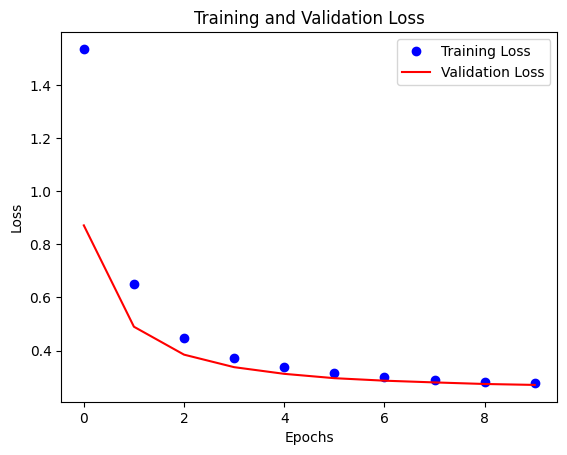

In [54]:
plt.plot(loss,'bo',label='Training Loss')
plt.plot(val_loss,'r',label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [55]:
preds=model.predict(x_test_f)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [56]:
x_test=x_test.reshape(10000,28,28)

In [61]:
np.argmax(preds[0])

7

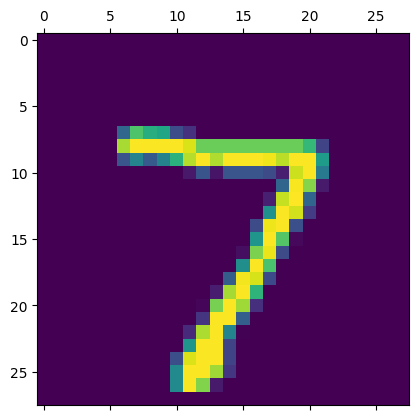

In [62]:
plt.matshow(x_test[0])

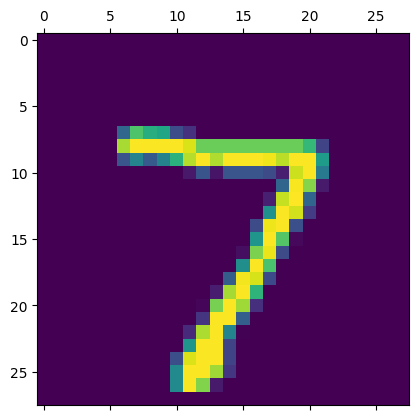

7


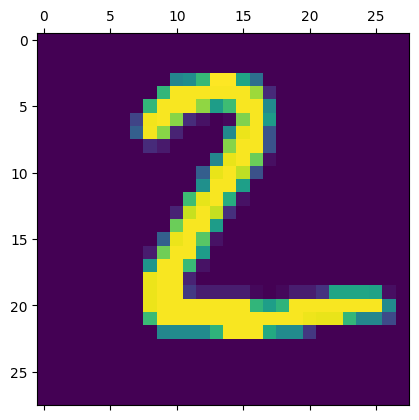

2


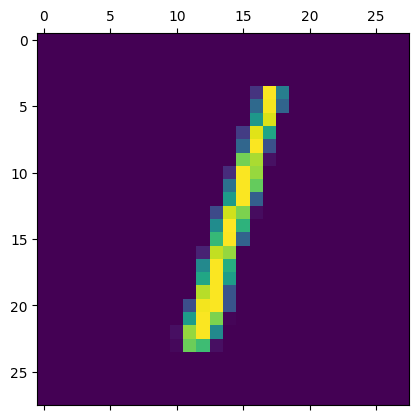

1


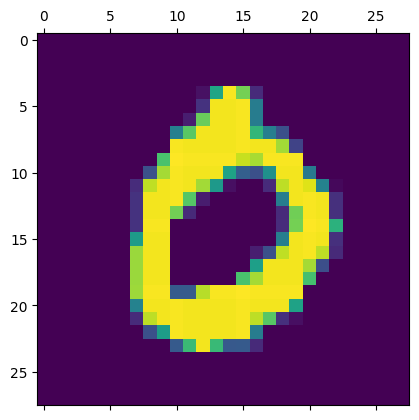

0


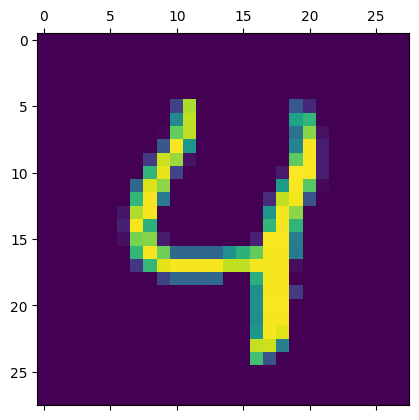

4


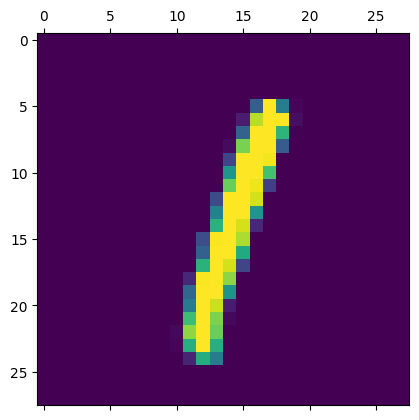

1


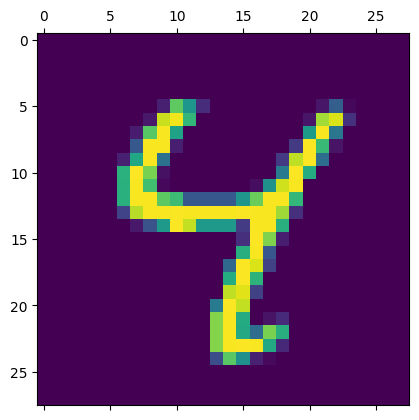

4


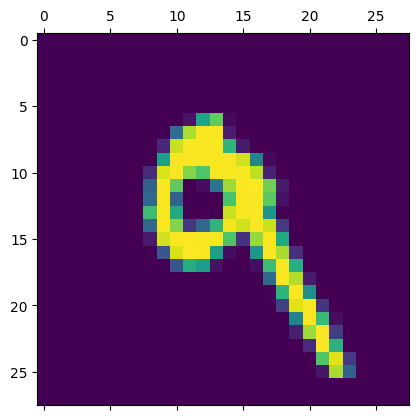

9


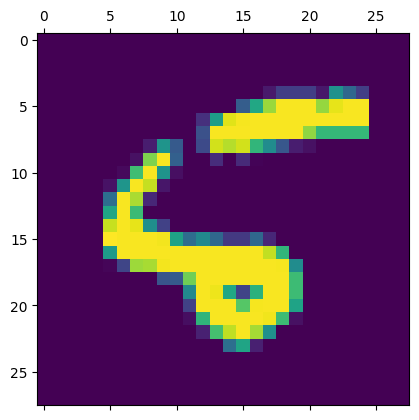

6


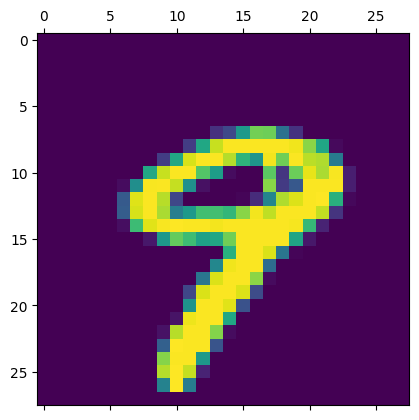

9


In [64]:
for i in range(10):
  plt.matshow(x_test[i])
  plt.show()
  print(np.argmax(preds[i]))